In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from xgcm import Grid

In [2]:
ds_seq0=xr.open_dataset('Files/seq0.nc')
ds_seq2=xr.open_dataset('Files/seq2.nc')
ds_seq3=xr.open_dataset('Files/seq3.nc')
ds_scurl0=xr.open_dataset('Files/scurl0.nc')
ds_eq0=xr.open_dataset('Files/eq0.nc')
ds_eq2=xr.open_dataset('Files/eq2.nc')
ds_eq3=xr.open_dataset('Files/eq3.nc')
ds_curl0=xr.open_dataset('Files/curl0.nc')

In [3]:
ds_stats1 = xr.open_dataset('Files/ocean_geometry.nc', decode_times=False)
ds_stats1 = ds_stats1.rename({'lath' : 'yh','lonh' : 'xh','latq' : 'yq','lonq' : 'xq'}) #renaming the coords to align with the original dataset
grid1 = Grid(ds_seq0, coords= {'X':{'center':'xh','outer':'xq'}, 'Y':{'center':'yh','outer':'yq'}, 'Z':{'center':'zl','outer':'zi'}},periodic=['X'])

# Depth Space

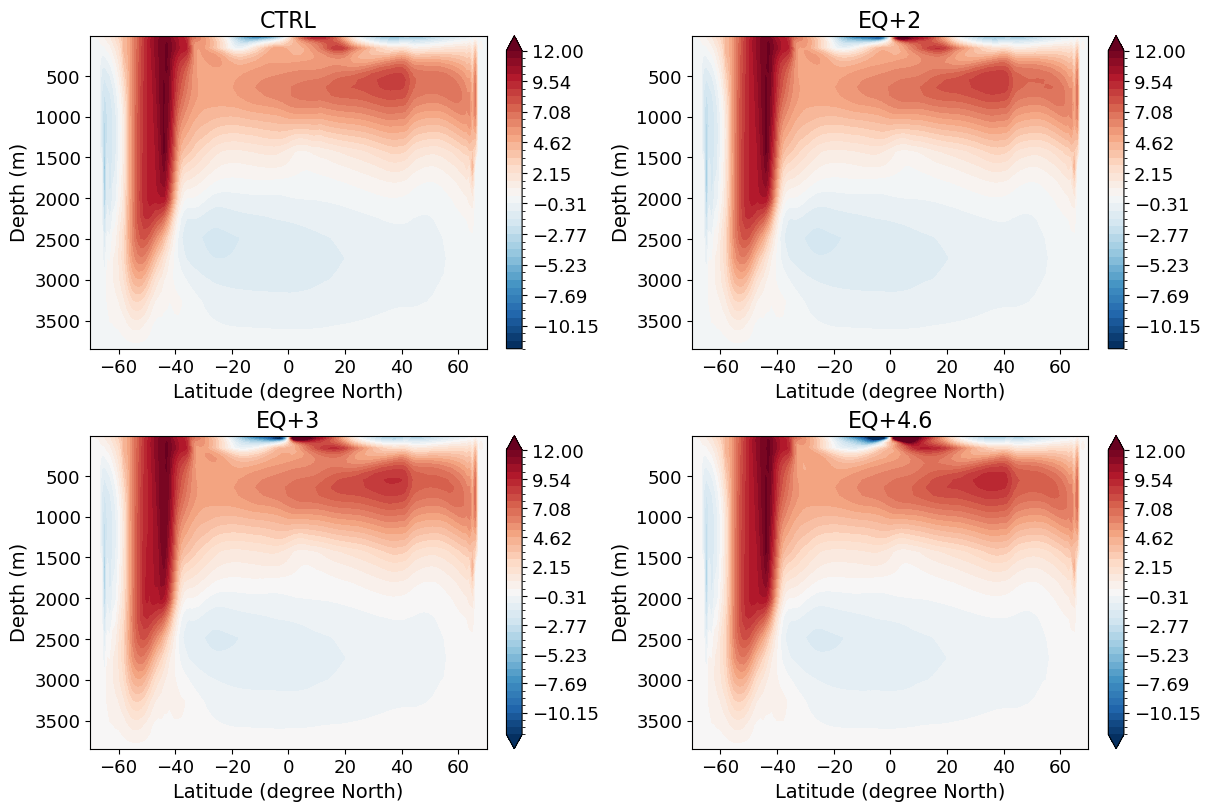

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize=(12, 8))

datasets = [ds_seq0, ds_seq2, ds_seq3, ds_scurl0]
titles = ["CTRL", "EQ+2", "EQ+3", "EQ+4.6"]

for i, axis in enumerate(ax.flat):
    contour = (((datasets[i].vh).sum('xh').cumsum('zl')) * 10**-6).plot.contourf(
        ax=axis, levels=40, cmap='RdBu_r', vmax=12, add_colorbar=False
    )
    axis.set_title(titles[i], fontsize=16)
    axis.set_xlabel('Latitude (degree North)', fontsize=14)
    axis.set_ylabel('Depth (m)', fontsize=14)
    axis.tick_params(axis='both', labelsize=13)
    axis.invert_yaxis()
    
    cbar = fig.colorbar(contour, ax=axis, orientation='vertical')
    cbar.ax.tick_params(labelsize=13)
    cbar.ax.set_label('Volume Transport (Sv)')

plt.show()

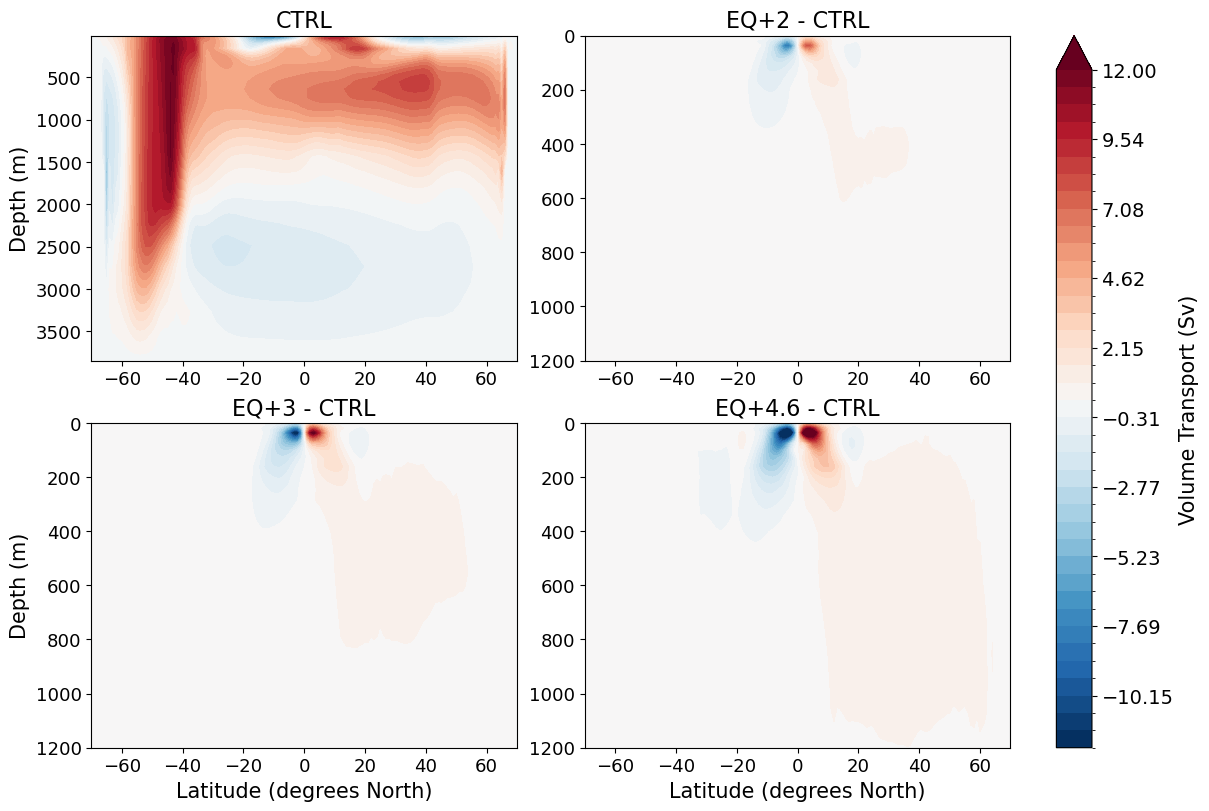

In [6]:
#Difference with the control run

fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize=(12, 8))

contour0 = (((ds_seq0.vh).sum('xh').cumsum('zl')) * 10**-6).plot.contourf(
    ax=ax[0, 0], levels=40, cmap='RdBu_r', vmax=12, add_colorbar=False
)
contour1 = ((((ds_seq2.vh).sum('xh').cumsum('zl')) * 10**-6) - (((ds_seq0.vh).sum('xh').cumsum('zl')) * 10**-6)).plot.contourf(
    ax=ax[0, 1], levels=40, cmap='RdBu_r', vmax=12, add_colorbar=False
)
contour2 = ((((ds_seq3.vh).sum('xh').cumsum('zl')) * 10**-6) - (((ds_seq0.vh).sum('xh').cumsum('zl')) * 10**-6)).plot.contourf(
    ax=ax[1, 0], levels=40, cmap='RdBu_r', vmax=12, add_colorbar=False
)
contour3 = ((((ds_scurl0.vh).sum('xh').cumsum('zl')) * 10**-6) - (((ds_seq0.vh).sum('xh').cumsum('zl')) * 10**-6)).plot.contourf(
    ax=ax[1, 1], levels=40, cmap='RdBu_r', vmax=12, add_colorbar=False
)

contours=[contour0,contour1,contour2,contour3]

ax[0, 0].set_title("CTRL", fontsize =16)
ax[0, 1].set_title("EQ+2 - CTRL", fontsize =16)
ax[1, 1].set_title("EQ+4.6 - CTRL", fontsize =16)
ax[1, 0].set_title("EQ+3 - CTRL", fontsize =16)

ax[0,0].tick_params(axis='both', labelsize=13)
ax[0,1].tick_params(axis='both', labelsize=13)
ax[1,0].tick_params(axis='both', labelsize=13)
ax[1,1].tick_params(axis='both', labelsize=13)

ax[0,0].set_xlabel('')
ax[0,1].set_xlabel('')
ax[1,0].set_xlabel("Latitude (degrees North)", fontsize = 15)
ax[1,1].set_xlabel("Latitude (degrees North)", fontsize = 15)


ax[0,0].set_ylabel("Depth (m)", fontsize = 15)
ax[0,1].set_ylabel('')
ax[1,0].set_ylabel("Depth (m)", fontsize = 15)
ax[1,1].set_ylabel('')

ax[0, 0].invert_yaxis()
ax[1, 0].invert_yaxis()
ax[0, 1].invert_yaxis()
ax[1, 1].invert_yaxis()

ax[1, 0].set_ylim(1200,0)
ax[0, 1].set_ylim(1200,0)
ax[1, 1].set_ylim(1200,0)

cbar = fig.colorbar(contours[0], ax=ax, orientation='vertical')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Volume Transport (Sv)', fontsize=15)  
plt.show()



# Density Space 

(1028.0, 1022.0)

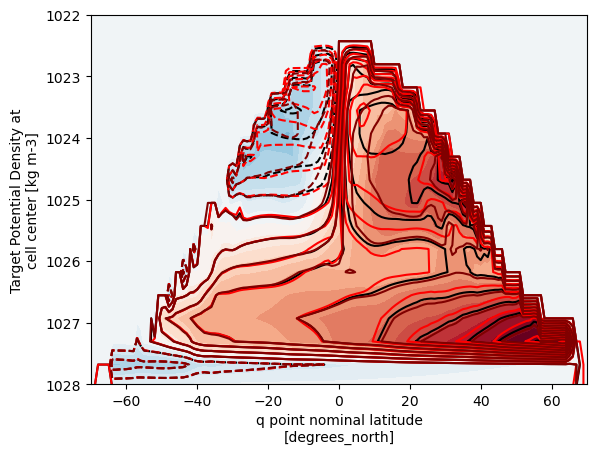

In [7]:
(((ds_seq0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9).plot.contourf(levels=30, cmap='RdBu_r', vmax=12, add_colorbar=False)
c=np.linspace(-12,12,1)
(((ds_seq3.vmo).sum('xh').cumsum('rho2_l')) * 10**-9).plot.contour(levels=30, colors='black')
(((ds_scurl0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9).plot.contour(levels=30, colors='red')
(((ds_seq2.vmo).sum('xh').cumsum('rho2_l')) * 10**-9).plot.contour(levels=30, colors='maroon')

plt.gca().invert_yaxis()
plt.gca().set_ylim(1028,1022)

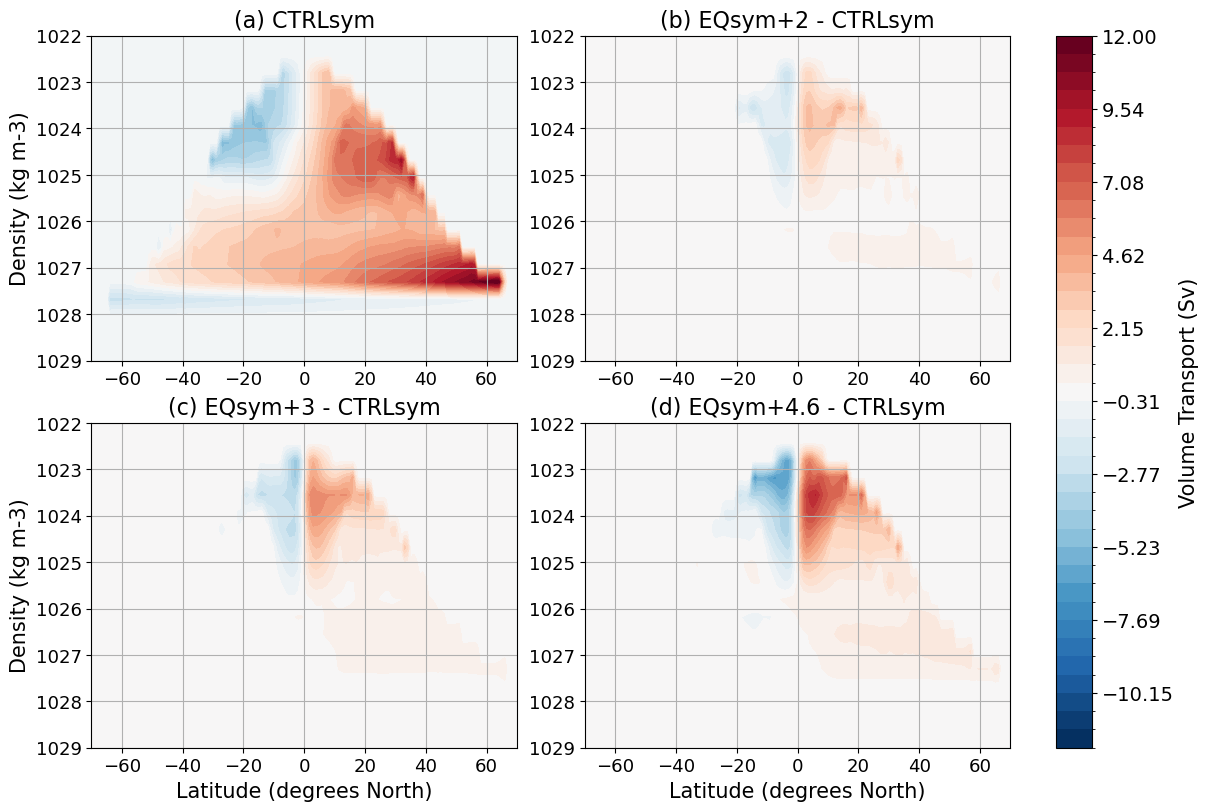

In [8]:
#Difference Plots
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize=(12, 8))


contour0 = (((ds_eq0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9).plot.contourf(
    ax=ax[0, 0], levels=40, cmap='RdBu_r',add_colorbar=False, vmax=12
)
contour1 = ((((ds_eq2.vmo).sum('xh').cumsum('rho2_l')) * 10**-9) - (((ds_eq0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9)).plot.contourf(
    ax=ax[0, 1], levels=40, cmap='RdBu_r', add_colorbar=False, vmax=12
)
contour2 = ((((ds_eq3.vmo).sum('xh').cumsum('rho2_l')) * 10**-9) - (((ds_eq0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9)).plot.contourf(
    ax=ax[1, 0], levels=40, cmap='RdBu_r', add_colorbar=False, vmax=12
)
contour3 = ((((ds_curl0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9) - (((ds_eq0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9)).plot.contourf(
    ax=ax[1, 1], levels=40, cmap='RdBu_r',add_colorbar=False, vmax=12
)

contours=[contour0,contour1,contour2,contour3]


ax[0, 0].set_title("(a) CTRLsym", fontsize =16)
ax[0, 1].set_title("(b) EQsym+2 - CTRLsym", fontsize =16)
ax[1, 1].set_title("(d) EQsym+4.6 - CTRLsym", fontsize =16)
ax[1, 0].set_title("(c) EQsym+3 - CTRLsym", fontsize =16)

ax[0,0].tick_params(axis='both', labelsize=13)
ax[0,1].tick_params(axis='both', labelsize=13)
ax[1,0].tick_params(axis='both', labelsize=13)
ax[1,1].tick_params(axis='both', labelsize=13)

ax[0,0].set_xlabel('')
ax[0,1].set_xlabel('')
ax[1,0].set_xlabel("Latitude (degrees North)", fontsize = 15)
ax[1,1].set_xlabel("Latitude (degrees North)", fontsize = 15)


ax[0,0].set_ylabel("Density (kg m-3)", fontsize = 15)
ax[0,1].set_ylabel('')
ax[1,0].set_ylabel("Density (kg m-3)", fontsize = 15)
ax[1,1].set_ylabel('')


ax[0, 0].invert_yaxis()
ax[1, 0].invert_yaxis()
ax[0, 1].invert_yaxis()
ax[1, 1].invert_yaxis()

ax[0, 0].set_ylim(1029,1022)
ax[1, 0].set_ylim(1029,1022)
ax[0, 1].set_ylim(1029,1022)
ax[1, 1].set_ylim(1029,1022)

ax[0, 0].grid()
ax[0, 1].grid()
ax[1, 0].grid()
ax[1, 1].grid()


cbar = fig.colorbar(contours[3], ax=ax, orientation='vertical')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Volume Transport (Sv)', fontsize=15) 

plt.show()

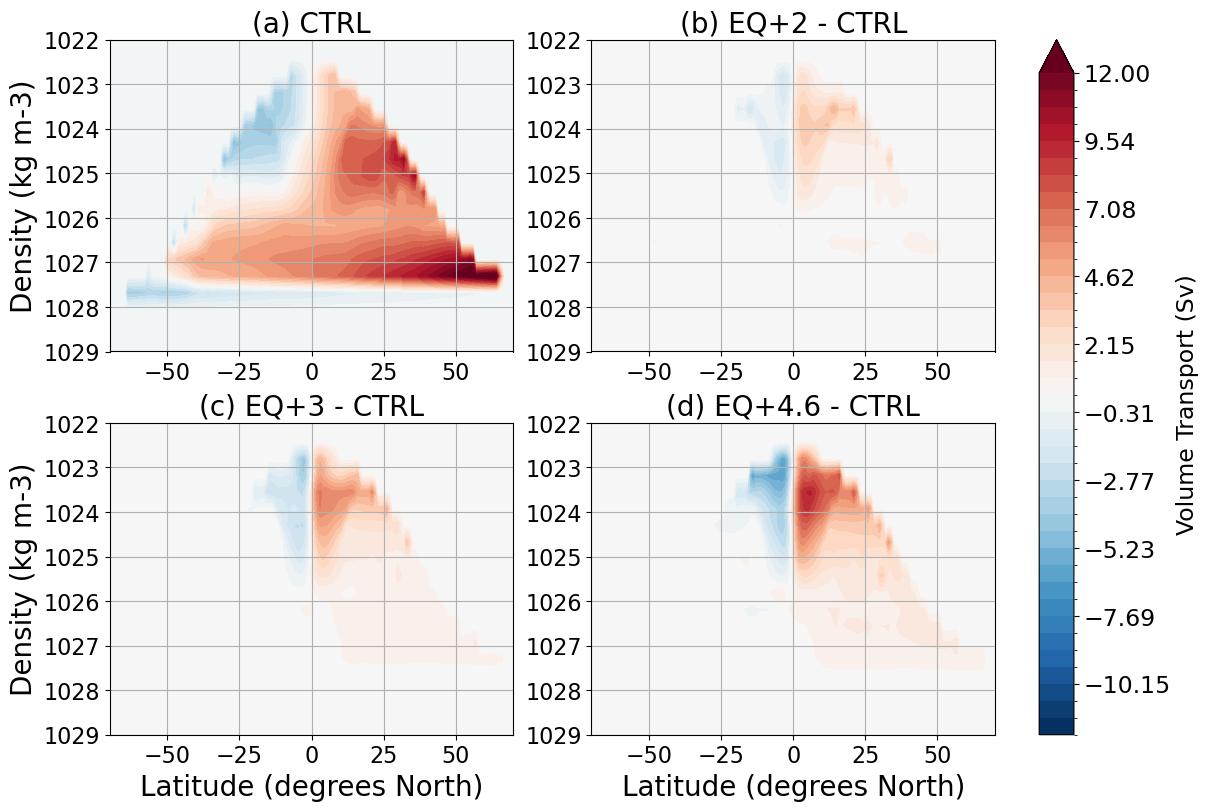

In [5]:
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize=(12, 8))

contour0 = (((ds_seq0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9).plot.contourf(
    ax=ax[0, 0], levels=40, cmap='RdBu_r',add_colorbar=False, vmax=12
)
contour1 = ((((ds_seq2.vmo).sum('xh').cumsum('rho2_l')) * 10**-9) - (((ds_seq0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9)).plot.contourf(
    ax=ax[0, 1], levels=40, cmap='RdBu_r', add_colorbar=False, vmax=12
)
contour2 = ((((ds_seq3.vmo).sum('xh').cumsum('rho2_l')) * 10**-9) - (((ds_seq0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9)).plot.contourf(
    ax=ax[1, 0], levels=40, cmap='RdBu_r', add_colorbar=False, vmax=12
)
contour3 = ((((ds_scurl0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9) - (((ds_seq0.vmo).sum('xh').cumsum('rho2_l')) * 10**-9)).plot.contourf(
    ax=ax[1, 1], levels=40, cmap='RdBu_r',add_colorbar=False, vmax=12
)

contours=[contour0,contour1,contour2,contour3]


ax[0, 0].set_title("(a) CTRL", fontsize =20)
ax[0, 1].set_title("(b) EQ+2 - CTRL", fontsize =20)
ax[1, 1].set_title("(d) EQ+4.6 - CTRL", fontsize =20)
ax[1, 0].set_title("(c) EQ+3 - CTRL", fontsize =20)

ax[0,0].tick_params(axis='both', labelsize=16)
ax[0,1].tick_params(axis='both', labelsize=16)
ax[1,0].tick_params(axis='both', labelsize=16)
ax[1,1].tick_params(axis='both', labelsize=16)

ax[0,0].set_xlabel('')
ax[0,1].set_xlabel('')
ax[1,0].set_xlabel("Latitude (degrees North)", fontsize = 20)
ax[1,1].set_xlabel("Latitude (degrees North)", fontsize = 20)


ax[0,0].set_ylabel("Density (kg m-3)", fontsize = 20)
ax[0,1].set_ylabel('')
ax[1,0].set_ylabel("Density (kg m-3)", fontsize = 20)
ax[1,1].set_ylabel('')


ax[0, 0].invert_yaxis()
ax[1, 0].invert_yaxis()
ax[0, 1].invert_yaxis()
ax[1, 1].invert_yaxis()

ax[0, 0].set_ylim(1029,1022)
ax[1, 0].set_ylim(1029,1022)
ax[0, 1].set_ylim(1029,1022)
ax[1, 1].set_ylim(1029,1022)

# ax[0, 0].axvline(x=42.5)
# ax[0, 1].axvline(x=42.5)
# ax[1, 0].axvline(x=42.5)
# ax[1, 1].axvline(x=42.5)

# ax[0, 0].axvline(x=-30)
# ax[0, 1].axvline(x=-30)
# ax[1, 0].axvline(x=-30)
# ax[1, 1].axvline(x=-30)

ax[0, 0].grid()
ax[0, 1].grid()
ax[1, 0].grid()
ax[1, 1].grid()

cbar = fig.colorbar(contours[0], ax=ax, orientation='vertical')
cbar.ax.tick_params(labelsize=17)
cbar.set_label('Volume Transport (Sv)', fontsize=17) 

# plt.show()

# Flow at the equator

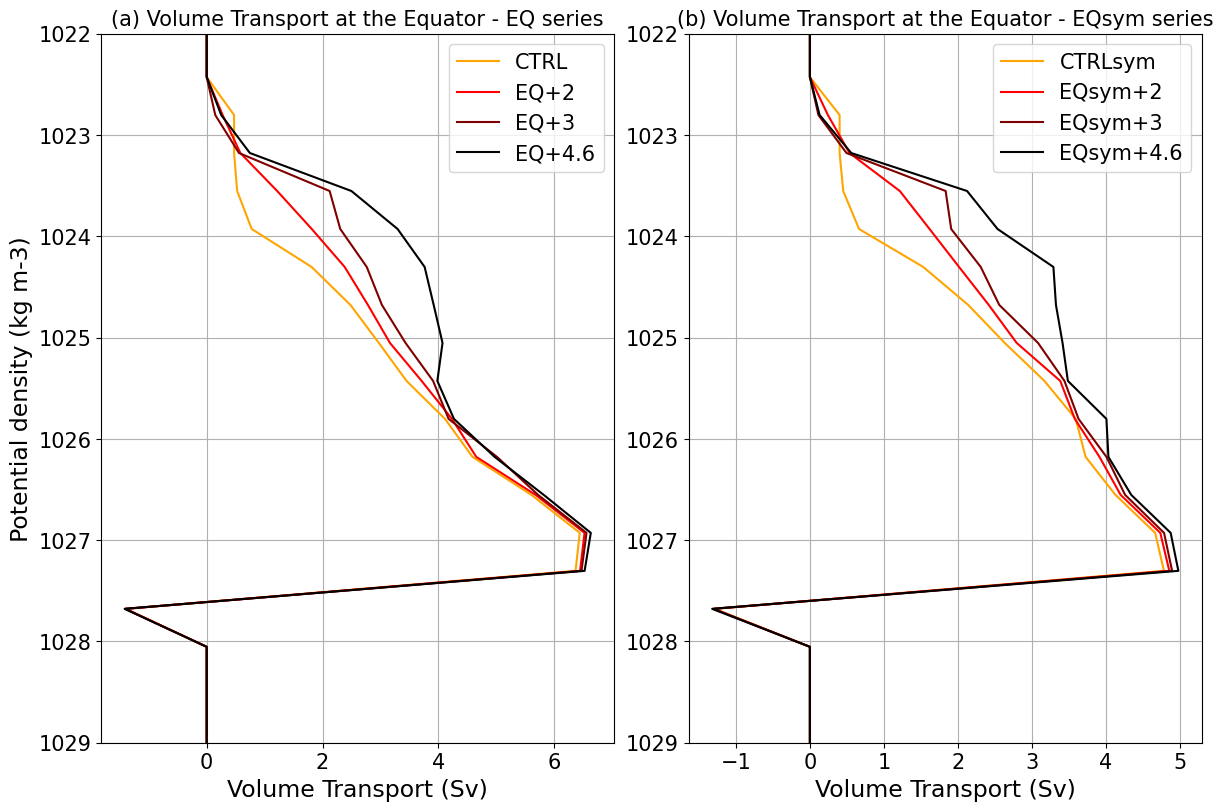

In [7]:
fig,ax=plt.subplots(nrows=1,ncols=2, constrained_layout=True,figsize=(12,8))
(((ds_seq0.vmo).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=70).plot(y='rho2_l',label = "CTRL", color = "orange", ax=ax[0])
(((ds_seq2.vmo).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=70).plot(y='rho2_l',label = "EQ+2", color = "red", ax=ax[0])
(((ds_seq3.vmo).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=70).plot(y='rho2_l',label = "EQ+3", color = "maroon", ax=ax[0])
(((ds_scurl0.vmo).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=70).plot(y='rho2_l',label = "EQ+4.6", color = "black", ax=ax[0])

(((ds_eq0.vmo).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=70).plot(y='rho2_l',label = "CTRLsym", color = "orange", ax=ax[1])
(((ds_eq2.vmo).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=70).plot(y='rho2_l',label = "EQsym+2", color = "red", ax=ax[1])
(((ds_eq3.vmo).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=70).plot(y='rho2_l',label = "EQsym+3", color = "maroon", ax=ax[1])
(((ds_curl0.vmo).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=70).plot(y='rho2_l',label = "EQsym+4.6", color = "black", ax=ax[1])

ax[0].set_title('(a) Volume Transport at the Equator - EQ series', fontsize=15)
ax[0].set_ylabel('Potential density (kg m-3)', fontsize=17)
ax[0].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[1].set_title('(b) Volume Transport at the Equator - EQsym series', fontsize=15)
ax[1].set_ylabel('', fontsize=17)
ax[1].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[0].tick_params(axis='both', labelsize=15)
ax[0].set_ylim(1022,1029)
ax[0].legend(loc="upper right",fontsize=15)
ax[0].grid()
ax[0].invert_yaxis()


ax[1].tick_params(axis='both', labelsize=15)
ax[1].set_ylim(1022,1029)
ax[1].legend(loc="upper right",fontsize=15)
ax[1].grid()
ax[1].invert_yaxis()


# Miscellaneous - Flow at the Eastern Boundary

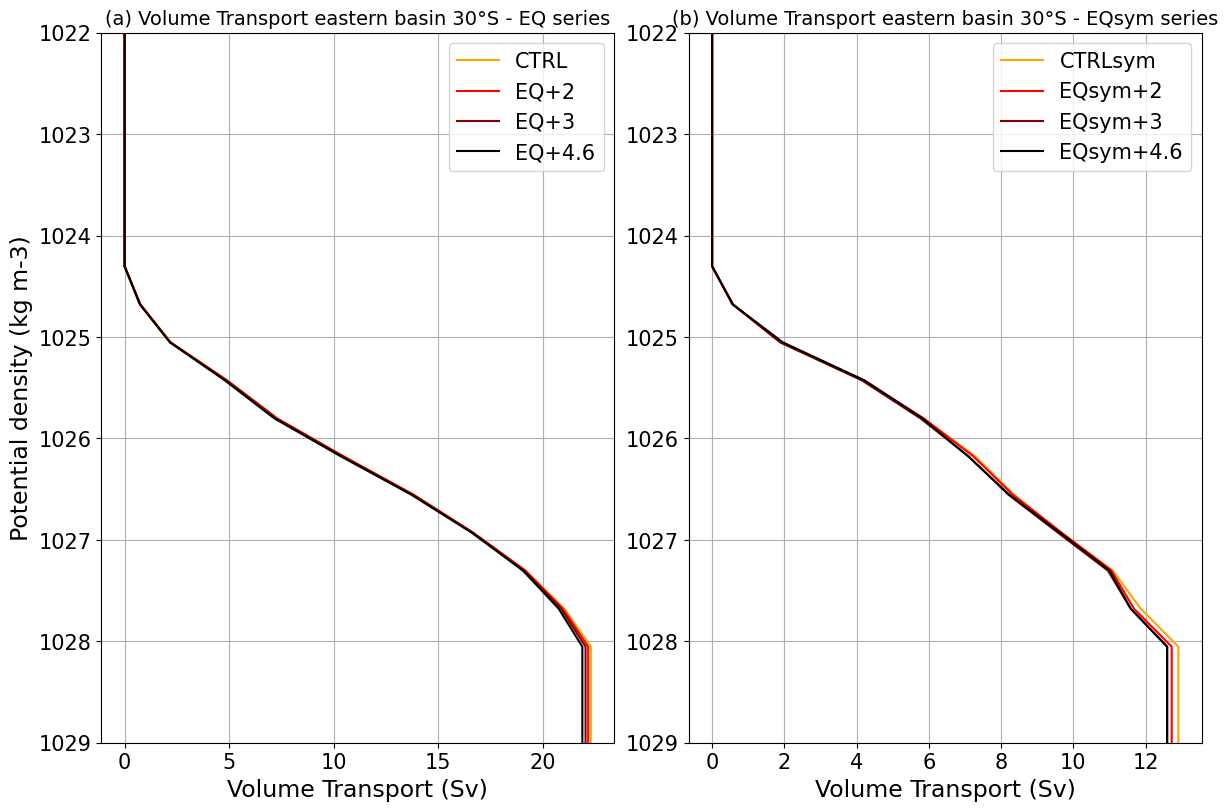

In [14]:
fig,ax=plt.subplots(nrows=1,ncols=2, constrained_layout=True,figsize=(12,8))
(((ds_seq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=40).plot(y='rho2_l',label = "CTRL", color = "orange", ax=ax[0])
(((ds_seq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=40).plot(y='rho2_l',label = "EQ+2", color = "red", ax=ax[0])
(((ds_seq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=40).plot(y='rho2_l',label = "EQ+3", color = "maroon", ax=ax[0])
(((ds_scurl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=40).plot(y='rho2_l',label = "EQ+4.6", color = "black", ax=ax[0])

(((ds_eq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=40).plot(y='rho2_l',label = "CTRLsym", color = "orange", ax=ax[1])
(((ds_eq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=40).plot(y='rho2_l',label = "EQsym+2", color = "red", ax=ax[1])
(((ds_eq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=40).plot(y='rho2_l',label = "EQsym+3", color = "maroon", ax=ax[1])
(((ds_curl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=40).plot(y='rho2_l',label = "EQsym+4.6", color = "black", ax=ax[1])

ax[0].set_title('(a) Volume Transport eastern basin 30\N{DEGREE SIGN}S - EQ series', fontsize=14)
ax[0].set_ylabel('Potential density (kg m-3)', fontsize=17)
ax[0].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[1].set_title('(b) Volume Transport eastern basin 30\N{DEGREE SIGN}S - EQsym series', fontsize=14)
ax[1].set_ylabel('', fontsize=17)
ax[1].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[0].tick_params(axis='both', labelsize=15)
ax[0].set_ylim(1022,1029)
ax[0].legend(loc="upper right",fontsize=15)
ax[0].grid()
ax[0].invert_yaxis()


ax[1].tick_params(axis='both', labelsize=15)
ax[1].set_ylim(1022,1029)
ax[1].legend(loc="upper right",fontsize=15)
ax[1].grid()
ax[1].invert_yaxis()

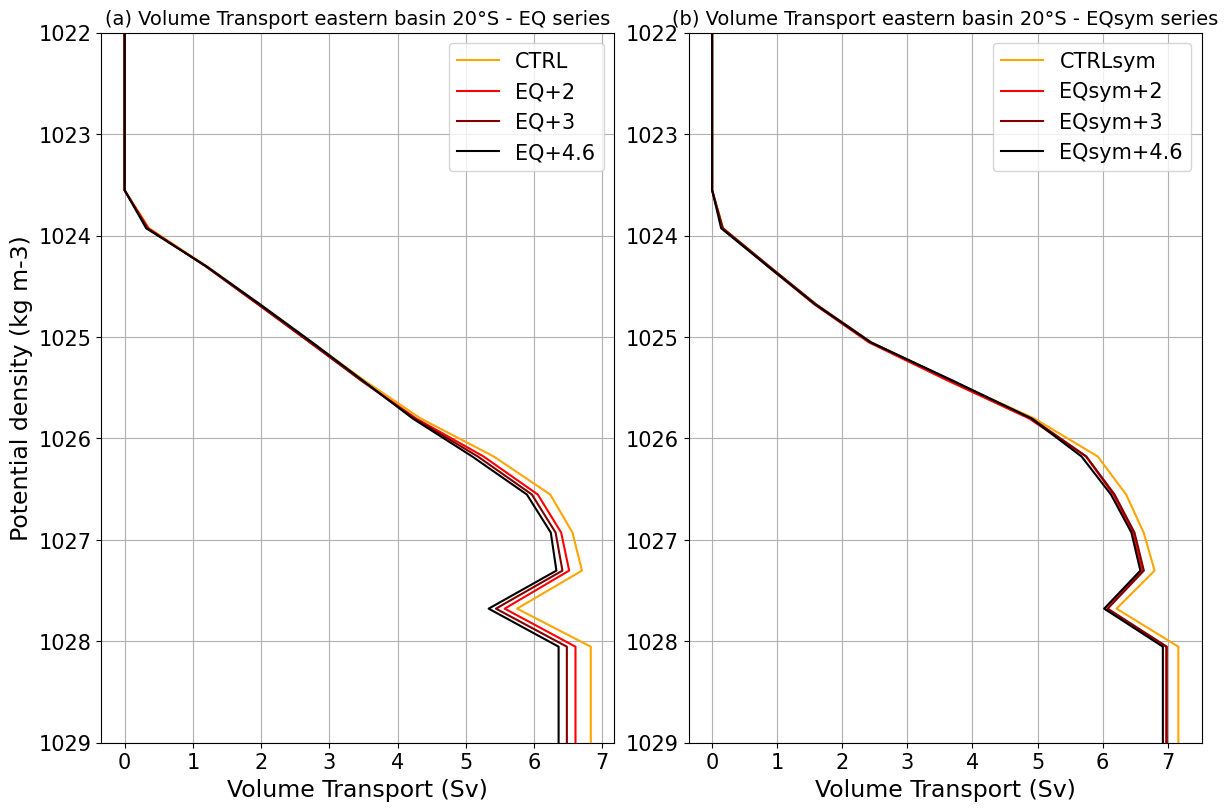

In [15]:
fig,ax=plt.subplots(nrows=1,ncols=2, constrained_layout=True,figsize=(12,8))
(((ds_seq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=50).plot(y='rho2_l',label = "CTRL", color = "orange", ax=ax[0])
(((ds_seq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=50).plot(y='rho2_l',label = "EQ+2", color = "red", ax=ax[0])
(((ds_seq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=50).plot(y='rho2_l',label = "EQ+3", color = "maroon", ax=ax[0])
(((ds_scurl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=50).plot(y='rho2_l',label = "EQ+4.6", color = "black", ax=ax[0])

(((ds_eq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=50).plot(y='rho2_l',label = "CTRLsym", color = "orange", ax=ax[1])
(((ds_eq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=50).plot(y='rho2_l',label = "EQsym+2", color = "red", ax=ax[1])
(((ds_eq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=50).plot(y='rho2_l',label = "EQsym+3", color = "maroon", ax=ax[1])
(((ds_curl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=50).plot(y='rho2_l',label = "EQsym+4.6", color = "black", ax=ax[1])

ax[0].set_title('(a) Volume Transport eastern basin 20\N{DEGREE SIGN}S - EQ series', fontsize=14)
ax[0].set_ylabel('Potential density (kg m-3)', fontsize=17)
ax[0].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[1].set_title('(b) Volume Transport eastern basin 20\N{DEGREE SIGN}S - EQsym series', fontsize=14)
ax[1].set_ylabel('', fontsize=17)
ax[1].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[0].tick_params(axis='both', labelsize=15)
ax[0].set_ylim(1022,1029)
ax[0].legend(loc="upper right",fontsize=15)
ax[0].grid()
ax[0].invert_yaxis()


ax[1].tick_params(axis='both', labelsize=15)
ax[1].set_ylim(1022,1029)
ax[1].legend(loc="upper right",fontsize=15)
ax[1].grid()
ax[1].invert_yaxis()

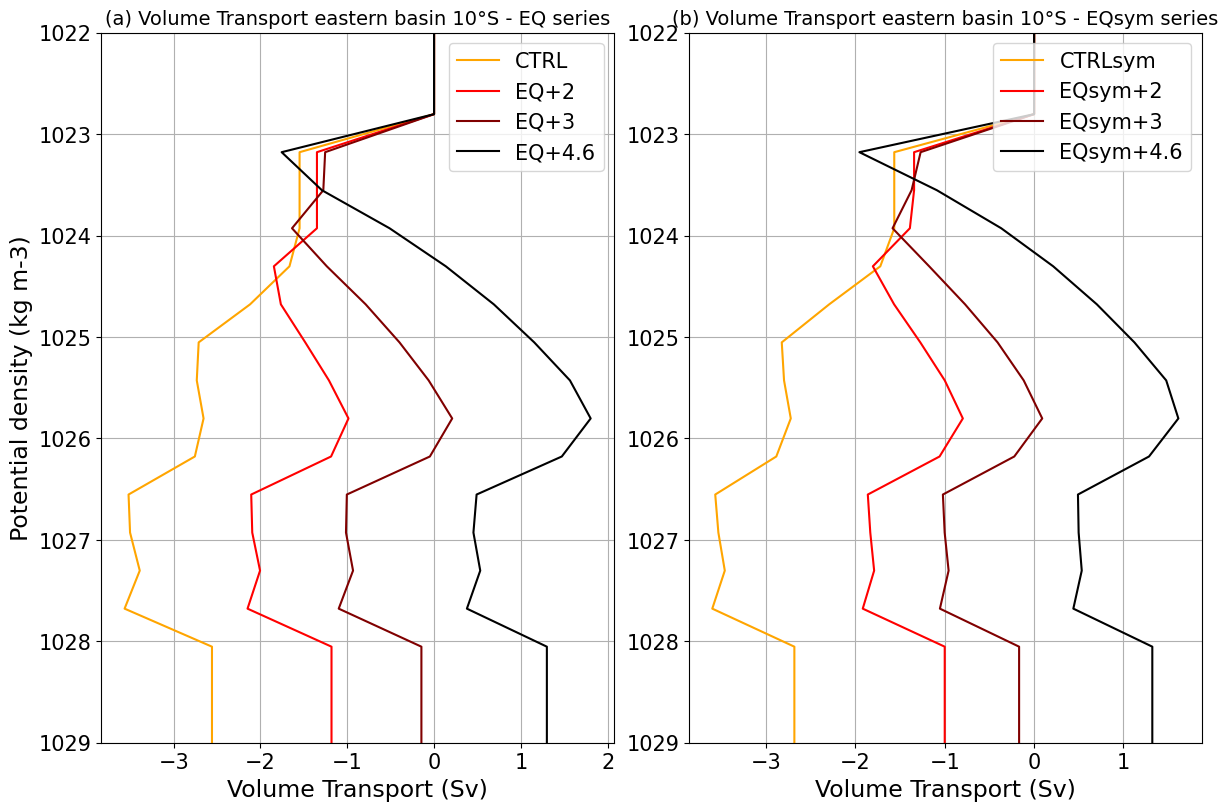

In [16]:
fig,ax=plt.subplots(nrows=1,ncols=2, constrained_layout=True,figsize=(12,8))
(((ds_seq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=60).plot(y='rho2_l',label = "CTRL", color = "orange", ax=ax[0])
(((ds_seq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=60).plot(y='rho2_l',label = "EQ+2", color = "red", ax=ax[0])
(((ds_seq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=60).plot(y='rho2_l',label = "EQ+3", color = "maroon", ax=ax[0])
(((ds_scurl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=60).plot(y='rho2_l',label = "EQ+4.6", color = "black", ax=ax[0])

(((ds_eq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=60).plot(y='rho2_l',label = "CTRLsym", color = "orange", ax=ax[1])
(((ds_eq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=60).plot(y='rho2_l',label = "EQsym+2", color = "red", ax=ax[1])
(((ds_eq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=60).plot(y='rho2_l',label = "EQsym+3", color = "maroon", ax=ax[1])
(((ds_curl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=60).plot(y='rho2_l',label = "EQsym+4.6", color = "black", ax=ax[1])

ax[0].set_title('(a) Volume Transport eastern basin 10\N{DEGREE SIGN}S - EQ series', fontsize=14)
ax[0].set_ylabel('Potential density (kg m-3)', fontsize=17)
ax[0].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[1].set_title('(b) Volume Transport eastern basin 10\N{DEGREE SIGN}S - EQsym series', fontsize=14)
ax[1].set_ylabel('', fontsize=17)
ax[1].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[0].tick_params(axis='both', labelsize=15)
ax[0].set_ylim(1022,1029)
ax[0].legend(loc="upper right",fontsize=15)
ax[0].grid()
ax[0].invert_yaxis()


ax[1].tick_params(axis='both', labelsize=15)
ax[1].set_ylim(1022,1029)
ax[1].legend(loc="upper right",fontsize=15)
ax[1].grid()
ax[1].invert_yaxis()

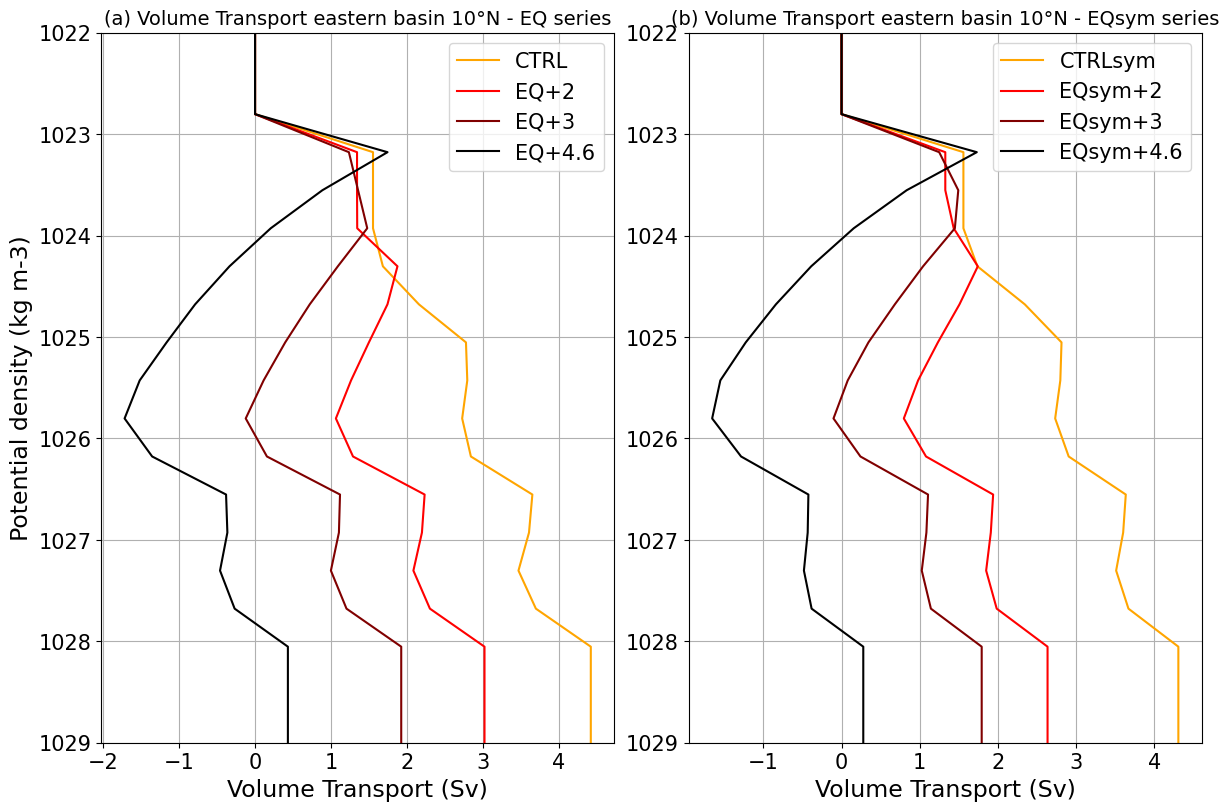

In [17]:
fig,ax=plt.subplots(nrows=1,ncols=2, constrained_layout=True,figsize=(12,8))
(((ds_seq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=80).plot(y='rho2_l',label = "CTRL", color = "orange", ax=ax[0])
(((ds_seq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=80).plot(y='rho2_l',label = "EQ+2", color = "red", ax=ax[0])
(((ds_seq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=80).plot(y='rho2_l',label = "EQ+3", color = "maroon", ax=ax[0])
(((ds_scurl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=80).plot(y='rho2_l',label = "EQ+4.6", color = "black", ax=ax[0])

(((ds_eq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=80).plot(y='rho2_l',label = "CTRLsym", color = "orange", ax=ax[1])
(((ds_eq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=80).plot(y='rho2_l',label = "EQsym+2", color = "red", ax=ax[1])
(((ds_eq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=80).plot(y='rho2_l',label = "EQsym+3", color = "maroon", ax=ax[1])
(((ds_curl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=80).plot(y='rho2_l',label = "EQsym+4.6", color = "black", ax=ax[1])

ax[0].set_title('(a) Volume Transport eastern basin 10\N{DEGREE SIGN}N - EQ series', fontsize=14)
ax[0].set_ylabel('Potential density (kg m-3)', fontsize=17)
ax[0].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[1].set_title('(b) Volume Transport eastern basin 10\N{DEGREE SIGN}N - EQsym series', fontsize=14)
ax[1].set_ylabel('', fontsize=17)
ax[1].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[0].tick_params(axis='both', labelsize=15)
ax[0].set_ylim(1022,1029)
ax[0].legend(loc="upper right",fontsize=15)
ax[0].grid()
ax[0].invert_yaxis()


ax[1].tick_params(axis='both', labelsize=15)
ax[1].set_ylim(1022,1029)
ax[1].legend(loc="upper right",fontsize=15)
ax[1].grid()
ax[1].invert_yaxis()

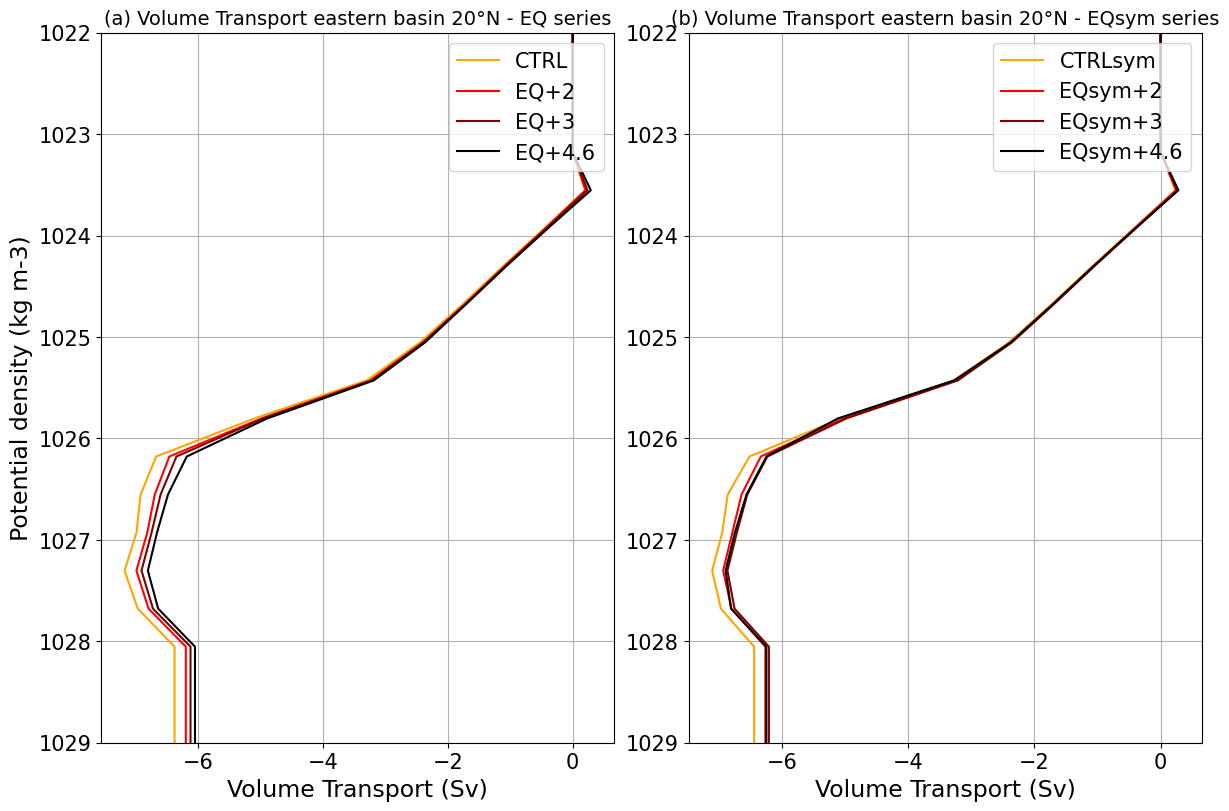

In [18]:
fig,ax=plt.subplots(nrows=1,ncols=2, constrained_layout=True,figsize=(12,8))
(((ds_seq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=90).plot(y='rho2_l',label = "CTRL", color = "orange", ax=ax[0])
(((ds_seq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=90).plot(y='rho2_l',label = "EQ+2", color = "red", ax=ax[0])
(((ds_seq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=90).plot(y='rho2_l',label = "EQ+3", color = "maroon", ax=ax[0])
(((ds_scurl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=90).plot(y='rho2_l',label = "EQ+4.6", color = "black", ax=ax[0])

(((ds_eq0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=90).plot(y='rho2_l',label = "CTRLsym", color = "orange", ax=ax[1])
(((ds_eq2.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=90).plot(y='rho2_l',label = "EQsym+2", color = "red", ax=ax[1])
(((ds_eq3.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=90).plot(y='rho2_l',label = "EQsym+3", color = "maroon", ax=ax[1])
(((ds_curl0.vmo).sel(xh=slice(50.5,79.5)).sum('xh').cumsum('rho2_l'))*10**-9).isel(yq=90).plot(y='rho2_l',label = "EQsym+4.6", color = "black", ax=ax[1])

ax[0].set_title('(a) Volume Transport eastern basin 20\N{DEGREE SIGN}N - EQ series', fontsize=14)
ax[0].set_ylabel('Potential density (kg m-3)', fontsize=17)
ax[0].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[1].set_title('(b) Volume Transport eastern basin 20\N{DEGREE SIGN}N - EQsym series', fontsize=14)
ax[1].set_ylabel('', fontsize=17)
ax[1].set_xlabel('Volume Transport (Sv)', fontsize=17)

ax[0].tick_params(axis='both', labelsize=15)
ax[0].set_ylim(1022,1029)
ax[0].legend(loc="upper right",fontsize=15)
ax[0].grid()
ax[0].invert_yaxis()


ax[1].tick_params(axis='both', labelsize=15)
ax[1].set_ylim(1022,1029)
ax[1].legend(loc="upper right",fontsize=15)
ax[1].grid()
ax[1].invert_yaxis()